In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ev_market_2026.csv to ev_market_2026 (1).csv


In [ ]:
df=pd.read_csv("ev_market_2026.csv")

In [ ]:
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


In [ ]:
df.shape

(2000, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  carg

In [ ]:
df.duplicated().value_counts()

,count
False,2000


In [ ]:
print(df.isnull().sum())

brand                    0
model                    0
year                     0
variant                  0
price_usd                0
battery_capacity_kwh     0
range_miles              0
charging_speed_kw        0
acceleration_0_60_mph    0
top_speed_mph            0
horsepower               0
torque_nm                0
drive_type               0
seating_capacity         0
body_type                0
cargo_volume_cubic_ft    0
weight_kg                0
safety_rating            0
autopilot_level          0
country_of_origin        0
market_segment           0
annual_sales_units       0
customer_rating          0
warranty_years           0
dtype: int64


In [ ]:
missing = df.isnull().sum()

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

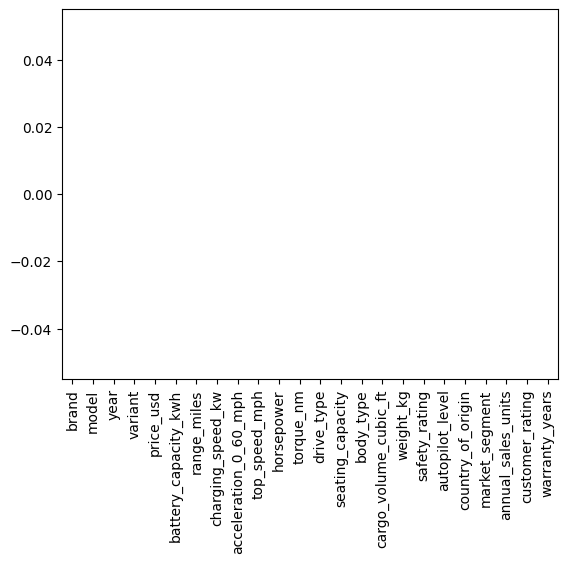

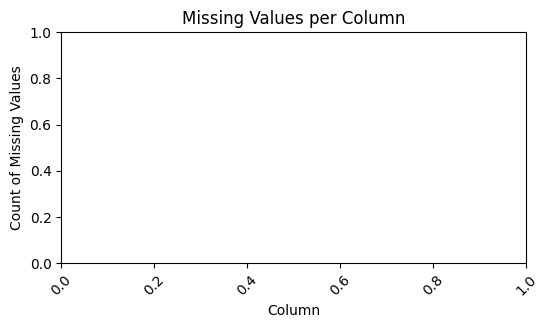

In [ ]:
# Create the bar plot
ax = missing.plot(kind='bar', color='skyblue')
plt.figure(figsize=(6, 3))
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)

# ✨ Add text labels above each bar
#for index, value in enumerate(missing):
#    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')
#plt.show()

In [ ]:
brand_counts = df['brand'].value_counts()
print("brand Counts:\n", brand_counts)

brand Counts:
 brand
Tesla           434
BYD             282
Volkswagen      194
Kia             166
Hyundai         152
BMW             150
GM/Chevrolet    143
Ford            129
Mercedes         96
Audi             77
Toyota           41
Rivian           37
Fisker           25
NIO              23
Porsche          14
Volvo            12
Polestar          9
Xiaomi            8
Lucid             6
Honda             2
Name: count, dtype: int64


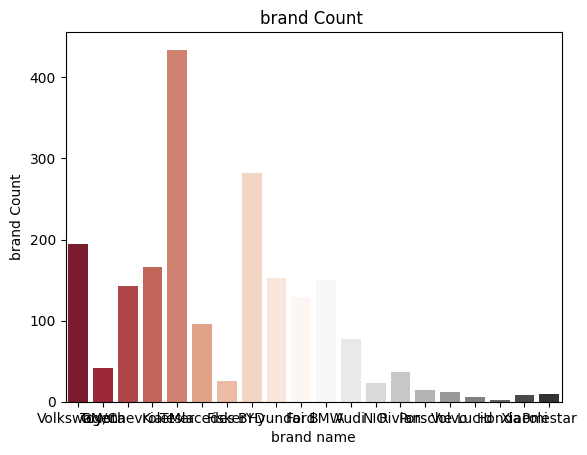

In [ ]:
sns.countplot(x='brand', hue='brand', data=df, palette=sns.color_palette("RdGy", 20), legend=False)
plt.title('brand Count ')
plt.xlabel('brand name')
plt.ylabel('brand Count')
plt.show()

In [ ]:
# Count of variant
variant_counts = df['variant'].value_counts()
print("\n Counts:\n", variant_counts)


 Counts:
 variant
Base           420
Long Range     407
Standard       403
Premium        392
Performance    378
Name: count, dtype: int64


In [ ]:
# Count of brand grouped by variant
brand_by_variant = df.groupby(['variant', 'brand']).size()
print("\n brand by var:\n", brand_by_variant)


 brand by var:
 variant   brand     
Base      Audi          28
          BMW           28
          BYD           64
          Fisker         6
          Ford          28
                        ..
Standard  Rivian        10
          Tesla         74
          Toyota         9
          Volkswagen    37
          Volvo          2
Length: 95, dtype: int64


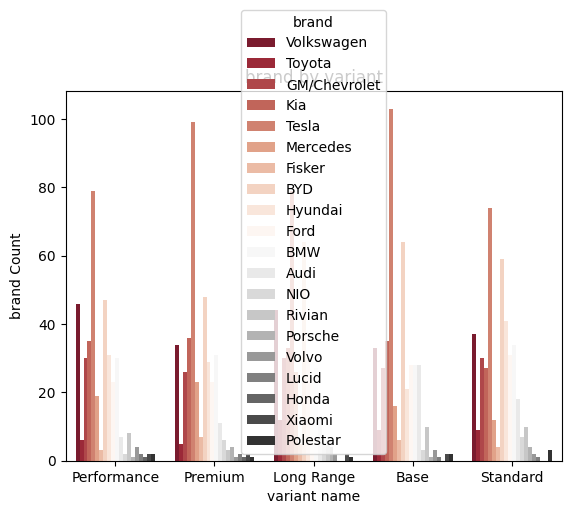

In [ ]:
sns.countplot(x='variant', hue='brand', data=df, palette=sns.color_palette("RdGy", 20))
plt.title('brand by variant')
plt.xlabel('variant name')
plt.ylabel('brand Count')
plt.legend(title='brand')
plt.show()

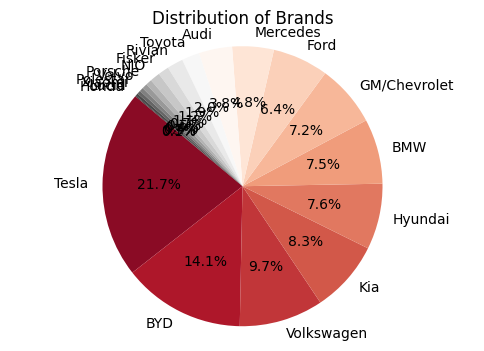

In [ ]:
plt.figure(figsize=(6,4))
plt.pie(brand_counts, labels=brand_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("RdGy", 20))
plt.title('Distribution of Brands')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

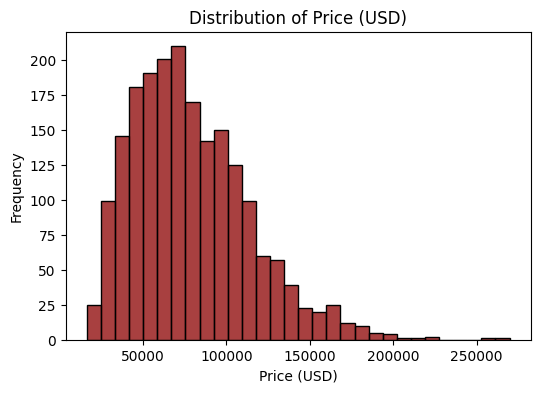

In [ ]:
plt.figure(figsize=(6, 4))
sns.histplot(df['price_usd'], kde=False, bins=30, color='#8B0000')
plt.title('Distribution of Price (USD)')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

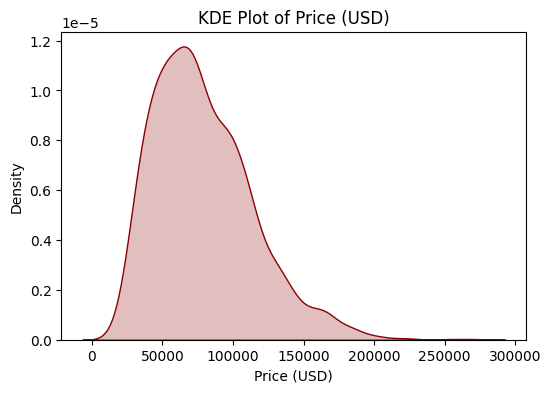

In [ ]:
plt.figure(figsize=(6, 4))
sns.kdeplot(df['price_usd'], fill=True, color='#8B0000')
plt.title('KDE Plot of Price (USD)')
plt.xlabel('Price (USD)')
plt.ylabel('Density')
plt.show()

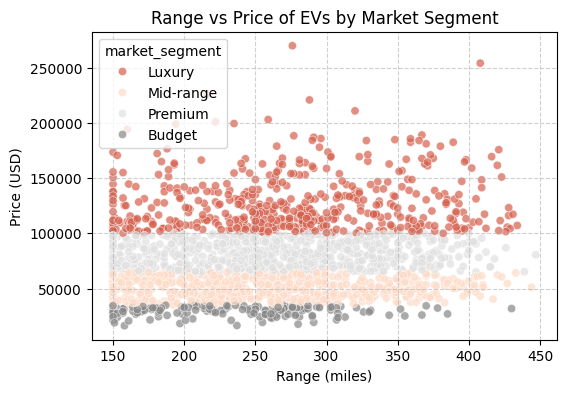

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='range_miles', y='price_usd', data=df, hue='market_segment', palette=sns.color_palette("RdGy", 4), alpha=0.7)
plt.title('Range vs Price of EVs by Market Segment')
plt.xlabel('Range (miles)')
plt.ylabel('Price (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
drive_type_counts = df['drive_type'].value_counts()
print("Drive Type Counts:\n", drive_type_counts)

Drive Type Counts:
 drive_type
AWD    754
RWD    678
FWD    568
Name: count, dtype: int64


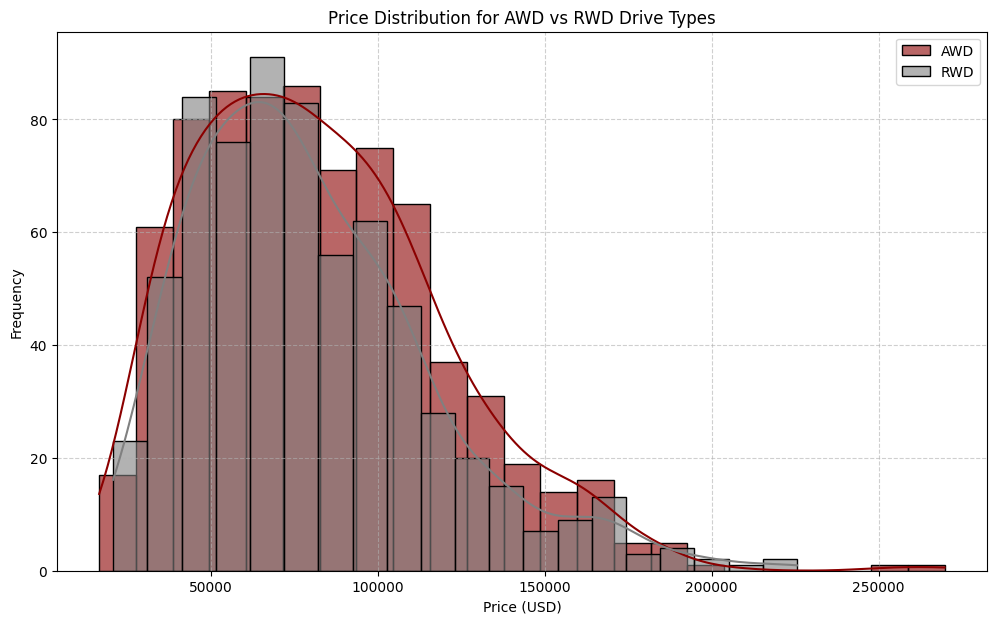

In [ ]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df[df['drive_type'] == 'AWD'], x='price_usd', color='#8B0000', label='AWD', kde=True, alpha=0.6)
sns.histplot(data=df[df['drive_type'] == 'RWD'], x='price_usd', color='#808080', label='RWD', kde=True, alpha=0.6)
plt.title('Price Distribution for AWD vs RWD Drive Types')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

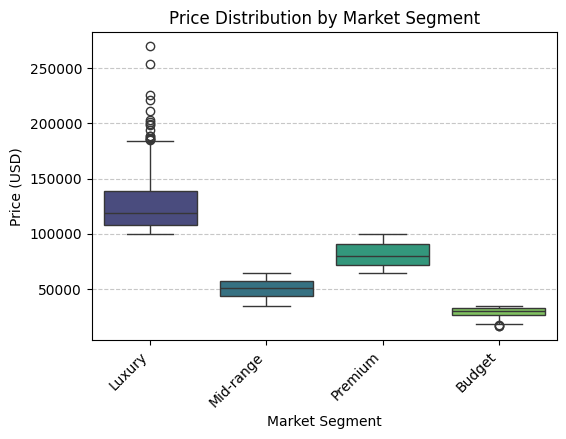

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='market_segment', y='price_usd', data=df, palette='viridis', hue='market_segment', legend=False)
plt.title('Price Distribution by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Conclusion from EDA

1.  **Data Quality:** The dataset is clean with no missing values or duplicate entries.
2.  **Brand Distribution:** Tesla, BYD, Volkswagen, Kia, and Hyundai are the most represented brands in the dataset.
3.  **Variant Distribution:** 'Base', 'Long Range', 'Standard', 'Premium', and 'Performance' variants are fairly evenly distributed.
4.  **Price Distribution:** The price of EVs varies widely, with a distribution that appears right-skewed, indicating a higher concentration of lower-priced vehicles and a tail of more expensive ones.
5.  **Range vs. Price:** There is a general positive correlation between range and price, with Luxury segment vehicles typically having both higher range and price.
6.  **Drive Type vs. Price:** AWD vehicles tend to have a different price distribution compared to RWD, suggesting that drive type is a factor influencing vehicle cost.
7.  **Market Segment vs. Price:** The price distribution varies significantly across different market segments, with 'Luxury' and 'Performance' segments commanding higher prices as expected.